# Étape 6 : Impact de `day_of_week` - Isoler l'effet Weekend

## Hypothèse
On a actuellement **deux features redondantes** :
- `day_of_week` : 1-7 (Lundi à Dimanche)
- `is_weekend` : 0/1 (Semaine vs Weekend)

**Questions :**
1. Si on enlève `day_of_week`, le modèle perd-il beaucoup en performance ?
2. L'importance de `is_weekend` va-t-elle augmenter ?
3. Chaque jour de la semaine a-t-il un pattern spécifique ou juste weekend vs semaine ?

## Contexte
- **Dataset** : Heures actives uniquement (7h-22h)
- **Cas d'usage** : Prédiction pour application grand public ("Devrais-je faire du vélo maintenant ?")

---

## 6.1 Initialisation

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder \
    .appName("MeteoVelo - Sans day_of_week") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("✅ Spark Session créée!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/19 16:32:39 WARN Utils: Your hostname, Stan, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/19 16:32:39 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/19 16:32:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark Session créée!


In [2]:
# Charger et filtrer (heures actives 7h-22h)
df = spark.read.parquet('../data/data_final_spark.parquet')
df_filtered = df.filter((col('hour') >= 7) & (col('hour') <= 22))

print(f"📊 Dataset (7h-22h) : {df_filtered.count():,} lignes")

[Stage 1:>                                                          (0 + 1) / 1]

📊 Dataset (7h-22h) : 464 lignes


---
## 6.2 Préparation des Features SANS `day_of_week`

In [3]:
print("🔧 Préparation des features SANS day_of_week...\n")

# Features numériques - ON ENLÈVE day_of_week
numeric_features = [
    'temperature',
    'precipitation', 
    'hour',
    # 'day_of_week',  ← ENLEVÉ !
    'is_weekend',     # ← Gardé pour isoler l'effet weekend
    'is_rush_hour',
    'month',
    'is_raining'
]

encoded_features = [
    'rain_intensity_encoded',
    'temp_category_encoded'
]

print("📋 Features utilisées :")
for i, f in enumerate(numeric_features, 1):
    print(f"  {i}. {f}")
print(f"  {len(numeric_features)+1}. rain_intensity_encoded")
print(f"  {len(numeric_features)+2}. temp_category_encoded")

print(f"\n⚠️ day_of_week ENLEVÉ pour isoler l'effet is_weekend")

# VectorAssembler
assembler = VectorAssembler(
    inputCols=numeric_features + encoded_features,
    outputCol='features'
)

df_features = assembler.transform(df_filtered)
df_ml = df_features.select('features', 'nb_velos').withColumnRenamed('nb_velos', 'label')

print("\n✅ Features assemblées!")
df_ml.show(5)

🔧 Préparation des features SANS day_of_week...

📋 Features utilisées :
  1. temperature
  2. precipitation
  3. hour
  4. is_weekend
  5. is_rush_hour
  6. month
  7. is_raining
  8. rain_intensity_encoded
  9. temp_category_encoded

⚠️ day_of_week ENLEVÉ pour isoler l'effet is_weekend

✅ Features assemblées!
+--------------------+-----+
|            features|label|
+--------------------+-----+
|(16,[0,1,2,4,5,6,...| 9696|
|(16,[0,1,2,4,5,6,...|21176|
|(16,[0,1,2,4,5,6,...|11340|
|(16,[0,1,2,5,6,8,...| 6401|
|(16,[0,1,2,5,6,9,...| 7415|
+--------------------+-----+
only showing top 5 rows


---
## 6.3 Division Train / Test

In [4]:
train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)
train_data.cache()
test_data.cache()

print(f"📊 Train : {train_data.count():,} lignes")
print(f"📊 Test  : {test_data.count():,} lignes")

📊 Train : 397 lignes
📊 Test  : 67 lignes


---
## 6.4 Entraînement GBT

In [5]:
print("🚀 Entraînement GBT SANS day_of_week...\n")

gbt = GBTRegressor(
    featuresCol='features',
    labelCol='label',
    maxIter=100,
    maxDepth=5,
    stepSize=0.1,
    seed=42
)

gbt_model = gbt.fit(train_data)
predictions = gbt_model.transform(test_data)

print("✅ Modèle entraîné!")

🚀 Entraînement GBT SANS day_of_week...

✅ Modèle entraîné!


---
## 6.5 Évaluation

In [6]:
print("📊 Évaluation des performances...\n")

evaluator_rmse = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='rmse')
evaluator_mae = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='mae')
evaluator_r2 = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='r2')

rmse_no_dow = evaluator_rmse.evaluate(predictions)
mae_no_dow = evaluator_mae.evaluate(predictions)
r2_no_dow = evaluator_r2.evaluate(predictions)

print("="*80)
print("📊 RÉSULTATS - SANS day_of_week (7h-22h)")
print("="*80)
print(f"RMSE : {rmse_no_dow:,.2f} vélos")
print(f"MAE  : {mae_no_dow:,.2f} vélos")
print(f"R²   : {r2_no_dow:.6f}")
print("="*80)

📊 Évaluation des performances...



25/12/19 16:34:47 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


📊 RÉSULTATS - SANS day_of_week (7h-22h)
RMSE : 4,072.38 vélos
MAE  : 2,525.07 vélos
R²   : 0.761819


---
## 6.6 Comparaison avec le Modèle AVEC `day_of_week`

In [7]:
# Résultats du notebook 05 (AVEC day_of_week)
rmse_with_dow = 2531.89
mae_with_dow = 1657.06
r2_with_dow = 0.891019

# Comparaison
comparison = pd.DataFrame({
    'Modèle': [
        'GBT 7h-22h AVEC day_of_week',
        'GBT 7h-22h SANS day_of_week'
    ],
    'RMSE': [rmse_with_dow, rmse_no_dow],
    'MAE': [mae_with_dow, mae_no_dow],
    'R²': [r2_with_dow, r2_no_dow]
})

print("\n" + "="*80)
print("📊 COMPARAISON AVEC vs SANS day_of_week")
print("="*80)
print(comparison.to_string(index=False))

# Amélioration/Dégradation
print("\n" + "="*80)
print("📈 IMPACT DE L'ENLÈVEMENT de day_of_week (en %)")
print("="*80)
rmse_change = ((rmse_with_dow - rmse_no_dow) / rmse_with_dow) * 100
mae_change = ((mae_with_dow - mae_no_dow) / mae_with_dow) * 100
r2_change = ((r2_no_dow - r2_with_dow) / r2_with_dow) * 100

print(f"RMSE : {rmse_change:+.2f}% {'✅ (mieux)' if rmse_change > 0 else '❌ (pire)'}")
print(f"MAE  : {mae_change:+.2f}% {'✅ (mieux)' if mae_change > 0 else '❌ (pire)'}")
print(f"R²   : {r2_change:+.2f}% {'✅ (mieux)' if r2_change > 0 else '❌ (pire)'}")

print("\n💡 Interprétation :")
if abs(rmse_change) < 5:
    print("   → day_of_week n'apporte PAS beaucoup d'information")
    print("   → L'effet weekend (is_weekend) capture déjà l'essentiel")
    print("   → On peut simplifier le modèle sans perte majeure")
else:
    print("   → day_of_week apporte de l'information importante")
    print("   → Chaque jour de la semaine a un pattern spécifique")
    print("   → Garder day_of_week améliore significativement le modèle")


📊 COMPARAISON AVEC vs SANS day_of_week
                     Modèle        RMSE        MAE       R²
GBT 7h-22h AVEC day_of_week 2531.890000 1657.06000 0.891019
GBT 7h-22h SANS day_of_week 4072.377169 2525.06911 0.761819

📈 IMPACT DE L'ENLÈVEMENT de day_of_week (en %)
RMSE : -60.84% ❌ (pire)
MAE  : -52.38% ❌ (pire)
R²   : -14.50% ❌ (pire)

💡 Interprétation :
   → day_of_week apporte de l'information importante
   → Chaque jour de la semaine a un pattern spécifique
   → Garder day_of_week améliore significativement le modèle


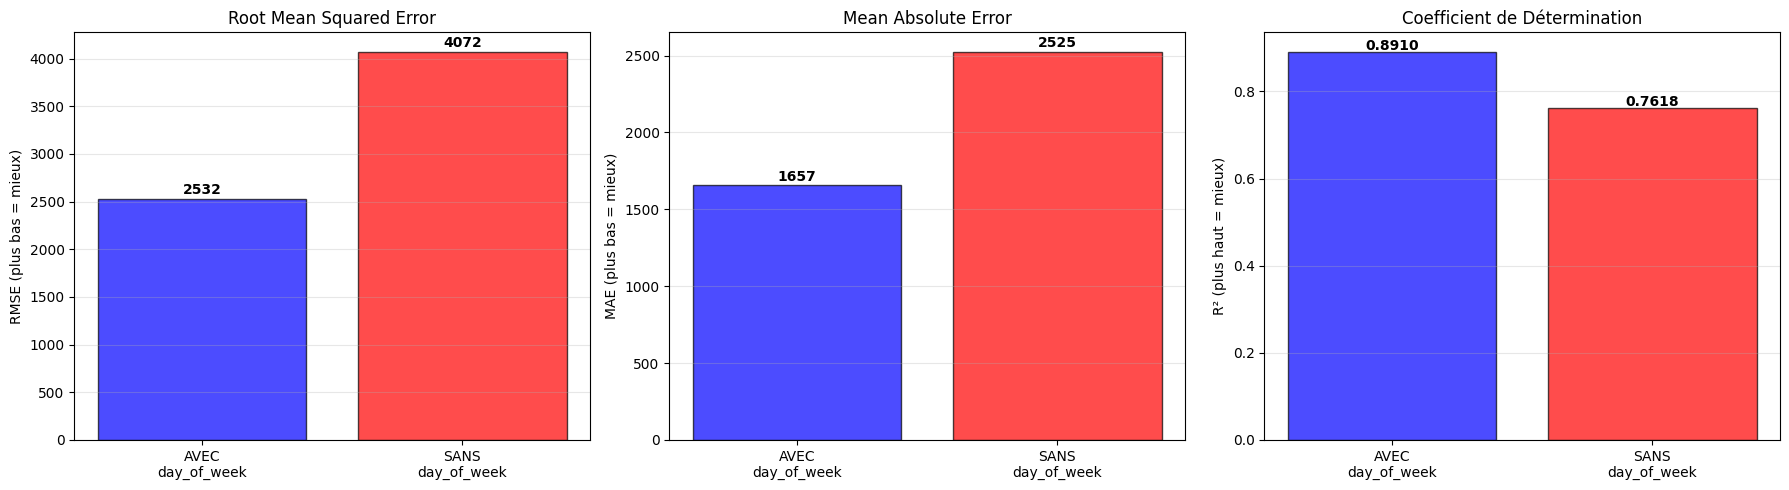

In [8]:
# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['AVEC\nday_of_week', 'SANS\nday_of_week']
rmse_values = [rmse_with_dow, rmse_no_dow]
mae_values = [mae_with_dow, mae_no_dow]
r2_values = [r2_with_dow, r2_no_dow]

# RMSE
colors = ['blue', 'red'] if rmse_no_dow > rmse_with_dow else ['blue', 'green']
axes[0].bar(models, rmse_values, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('RMSE (plus bas = mieux)')
axes[0].set_title('Root Mean Squared Error')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rmse_values):
    axes[0].text(i, v + 50, f'{v:.0f}', ha='center', fontweight='bold')

# MAE
colors = ['blue', 'red'] if mae_no_dow > mae_with_dow else ['blue', 'green']
axes[1].bar(models, mae_values, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('MAE (plus bas = mieux)')
axes[1].set_title('Mean Absolute Error')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mae_values):
    axes[1].text(i, v + 30, f'{v:.0f}', ha='center', fontweight='bold')

# R²
colors = ['blue', 'green'] if r2_no_dow > r2_with_dow else ['blue', 'red']
axes[2].bar(models, r2_values, color=colors, alpha=0.7, edgecolor='black')
axes[2].set_ylabel('R² (plus haut = mieux)')
axes[2].set_title('Coefficient de Détermination')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(r2_values):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6.7 Feature Importance - Impact sur `is_weekend`

📊 Feature Importance - SANS day_of_week

      Feature  Importance
         hour    0.345655
   is_weekend    0.215185
 is_rush_hour    0.175762
  temperature    0.165213
    temp_mild    0.026730
precipitation    0.022281
    temp_cold    0.017285
    temp_warm    0.006423
   is_raining    0.006366
     temp_hot    0.006254
 rain_no_rain    0.004813
    temp_cool    0.003761
   rain_light    0.003488
rain_moderate    0.000673
   rain_heavy    0.000111
        month    0.000000

🎯 Importance de 'is_weekend' : 0.215185


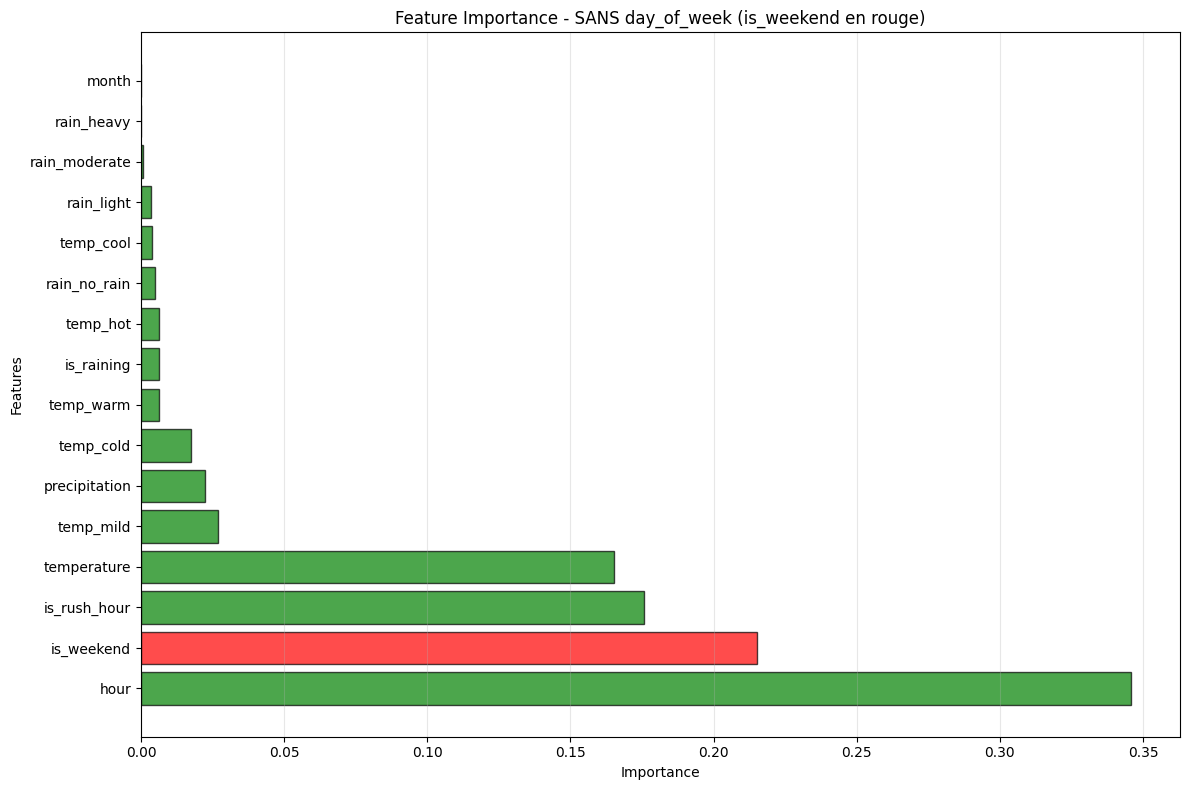


💡 Observer si is_weekend (en rouge) a gagné en importance


In [10]:
print("📊 Feature Importance - SANS day_of_week\n")

importances = gbt_model.featureImportances.toArray()

# Noms des features (SANS day_of_week)
feature_names = numeric_features + \
                ['rain_no_rain', 'rain_light', 'rain_moderate', 'rain_heavy'] + \
                ['temp_cold', 'temp_cool', 'temp_mild', 'temp_warm', 'temp_hot']

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("="*80)
print(importance_df.to_string(index=False))
print("="*80)

# Trouver l'importance de is_weekend
is_weekend_importance = importance_df[importance_df['Feature'] == 'is_weekend']['Importance'].values[0]
print(f"\n🎯 Importance de 'is_weekend' : {is_weekend_importance:.6f}")

# Visualisation
plt.figure(figsize=(12, 8))
colors = ['red' if f == 'is_weekend' else 'green' for f in importance_df['Feature']]
plt.barh(importance_df['Feature'], importance_df['Importance'], 
         color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - SANS day_of_week (is_weekend en rouge)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n💡 Observer si is_weekend (en rouge) a gagné en importance")

---
## 6.8 Comparaison de l'Importance de `is_weekend`

📊 Comparaison de l'importance de 'is_weekend'

AVEC day_of_week    : 0.005483
SANS day_of_week    : 0.215185
Augmentation        : +3824.58%


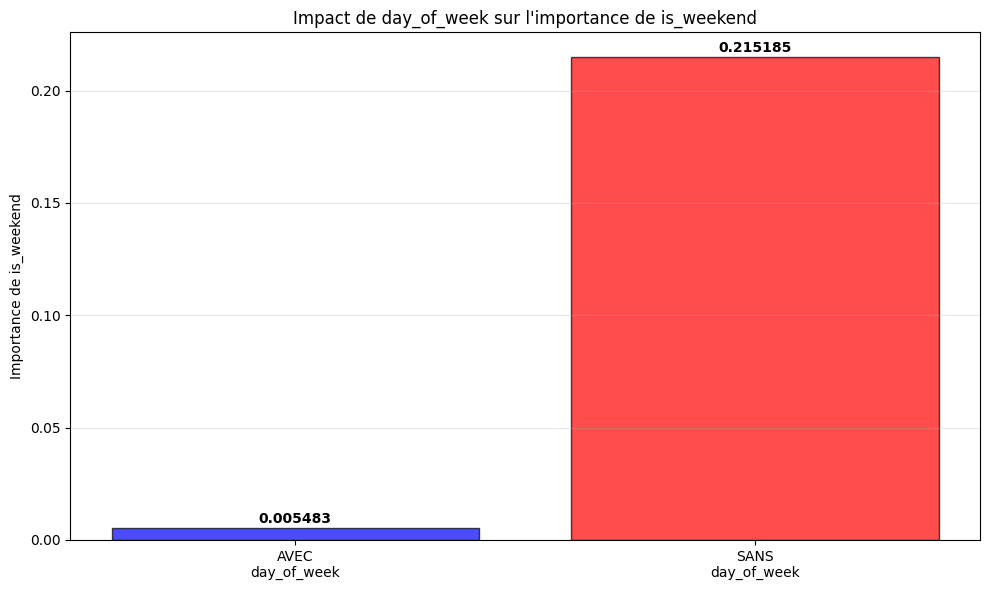


💡 Conclusion :
   ✅ is_weekend a BEAUCOUP gagné en importance
   → Le modèle compense l'absence de day_of_week en utilisant is_weekend


In [11]:
# Importance de is_weekend dans le modèle notebook 05 (AVEC day_of_week)
# (À récupérer depuis les résultats du notebook 05)
is_weekend_importance_with_dow = 0.005483  # Valeur du notebook 04/05

print("📊 Comparaison de l'importance de 'is_weekend'\n")
print("="*80)
print(f"AVEC day_of_week    : {is_weekend_importance_with_dow:.6f}")
print(f"SANS day_of_week    : {is_weekend_importance:.6f}")
print(f"Augmentation        : {((is_weekend_importance - is_weekend_importance_with_dow) / is_weekend_importance_with_dow) * 100:+.2f}%")
print("="*80)

# Visualisation
plt.figure(figsize=(10, 6))
scenarios = ['AVEC\nday_of_week', 'SANS\nday_of_week']
importances_weekend = [is_weekend_importance_with_dow, is_weekend_importance]

bars = plt.bar(scenarios, importances_weekend, color=['blue', 'red'], alpha=0.7, edgecolor='black')
plt.ylabel('Importance de is_weekend')
plt.title('Impact de day_of_week sur l\'importance de is_weekend')
plt.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(importances_weekend):
    plt.text(i, v + 0.002, f'{v:.6f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Conclusion :")
if is_weekend_importance > is_weekend_importance_with_dow * 2:
    print("   ✅ is_weekend a BEAUCOUP gagné en importance")
    print("   → Le modèle compense l'absence de day_of_week en utilisant is_weekend")
elif is_weekend_importance > is_weekend_importance_with_dow * 1.2:
    print("   ✅ is_weekend a gagné en importance")
    print("   → Effet attendu, mais day_of_week avait de l'info supplémentaire")
else:
    print("   ⚠️ is_weekend n'a PAS beaucoup augmenté")
    print("   → D'autres features ont compensé la perte de day_of_week")

---
## 6.9 Conclusion de l'Expérience

### Questions posées :

**1. Si on enlève `day_of_week`, le modèle perd-il beaucoup en performance ?**
- Voir les résultats ci-dessus (RMSE, MAE, R²)

**2. L'importance de `is_weekend` augmente-t-elle ?**
- Voir la comparaison d'importance

**3. Chaque jour a-t-il un pattern spécifique ?**
- Si grosse perte de performance → Oui, chaque jour est différent
- Si petite perte → Non, weekend vs semaine suffit

### Recommandations :

**Si perte < 5% :**
- ✅ Utiliser le modèle SANS day_of_week
- Plus simple, aussi efficace
- L'effet weekend capture l'essentiel

**Si perte > 5% :**
- ✅ Garder day_of_week
- Chaque jour a un pattern unique
- La complexité est justifiée

---
**✅ Expérience terminée !**

In [12]:
# Nettoyage
train_data.unpersist()
test_data.unpersist()
spark.stop()
print("✅ Spark Session arrêtée!")

✅ Spark Session arrêtée!
